## MSA-I2A Google Colab / Jupyter Notebook

**Mood-and-Structure-Aware Image-to-Audio Synthesis via Valence-Arousal-Guided Alignment**

> Important: this Version 1 prototype generates a mel-spectrogram-like representation, not a high-quality waveform comparable to a full AudioLDM-scale model.

## CELL 1 — Check GPU

In [ ]:
!nvidia-smi

Tue Aug 25 00:34:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CELL 2 — Install Libraries

Install all required dependencies. Restart the runtime if Colab asks you to.

In [ ]:
!pip -q install transformers
!pip -q install datasets
!pip -q install accelerate
!pip -q install librosa
!pip -q install soundfile
!pip -q install torchmetrics
!pip -q install scipy
!pip -q install matplotlib
!pip -q install tqdm
!pip -q install einops
!pip -q install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.8 MB/s eta 0:00:00


## CELL 3 — Import Libraries

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import librosa
import librosa.display
import soundfile as sf

from PIL import Image

from transformers import CLIPProcessor, CLIPModel

from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: cuda


## CELL 4 — Set Random Seed

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## CELL 5A — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## CELL 5B — Create Project Folders

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/MSA_I2A"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data/images", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data/audio", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/results", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/generated_audio", exist_ok=True)

print("Project directory created:")
print(PROJECT_DIR)

Project directory created:
/content/drive/MyDrive/MSA_I2A


## CELL 6 — Dataset Structure

Expected structure:

```text
MSA_I2A/
├── data/
│   ├── images/
│   └── audio/
├── metadata.csv
├── checkpoints/
├── results/
└── generated_audio/
```

Expected metadata columns: `image,audio,valence,arousal`.

## CELL 7 — Optional Direct Upload

In [ ]:
from google.colab import files

# Uncomment only if you want to upload files directly.
# uploaded = files.upload()

print("Place images in:")
print(f"{PROJECT_DIR}/data/images/")
print("Place audio in:")
print(f"{PROJECT_DIR}/data/audio/")

Place images in:
/content/drive/MyDrive/MSA_I2A/data/images/
Place audio in:
/content/drive/MyDrive/MSA_I2A/data/audio/


## CELL 8 — Load Metadata

In [ ]:
METADATA_PATH = f"{PROJECT_DIR}/metadata.csv"

df = pd.read_csv(METADATA_PATH)

required_columns = {"image", "audio", "valence", "arousal"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"metadata.csv is missing columns: {missing_columns}")

print("Dataset size:", len(df))
display(df.head())

Dataset size: 10


,image,audio,valence,arousal
0,image_0.png,audio_0.wav,0.374540,0.020584
1,image_1.png,audio_1.wav,0.950714,0.969910
2,image_2.png,audio_2.wav,0.731994,0.832443
3,image_3.png,audio_3.wav,0.598658,0.212339
4,image_4.png,audio_4.wav,0.156019,0.181825


### Troubleshooting: `FileNotFoundError` for `metadata.csv`

The previous cell failed because `metadata.csv` was not found at the expected path: `/content/drive/MyDrive/MSA_I2A/metadata.csv`.

Please ensure that you have uploaded your `metadata.csv` file to the `MSA_I2A` folder in your Google Drive. If you haven't, you can use the following code cell to upload it directly to the root of the Colab environment. After uploading, you will need to move it to the correct `PROJECT_DIR` or re-upload it directly to the `PROJECT_DIR` in your Google Drive.

**Option 1: Manually place `metadata.csv` in your Google Drive**

1.  Go to your Google Drive.
2.  Navigate to `MyDrive/MSA_I2A/`.
3.  Upload `metadata.csv` directly into this folder.

**Option 2: Upload using Colab's `files.upload()` and move it (if you don't want to use Google Drive directly)**

Run the cell below, select your `metadata.csv` file from your local machine, and then move it to the `PROJECT_DIR`.

In [ ]:
import shutil
from google.colab import files

print(f"Please upload your metadata.csv to {PROJECT_DIR}/")

# This will open a file picker for you to select metadata.csv
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Move the uploaded file to the project directory
  shutil.move(fn, os.path.join(PROJECT_DIR, fn))

print(f"File '{fn}' moved to {PROJECT_DIR}/{fn}")

# After successfully uploading and moving, please re-run CELL 8 to load the metadata.

Please upload your metadata.csv to /content/drive/MyDrive/MSA_I2A/


Saving metadata.csv to metadata (2).csv
User uploaded file "metadata (2).csv" with length 657 bytes
File 'metadata (2).csv' moved to /content/drive/MyDrive/MSA_I2A/metadata (2).csv


## CELL 9A — Train / Validation / Test Split

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6
Validation: 2
Test: 2


## CELL 9B — Save Dataset Splits

In [ ]:
train_df.to_csv(f"{PROJECT_DIR}/train.csv", index=False)
val_df.to_csv(f"{PROJECT_DIR}/val.csv", index=False)
test_df.to_csv(f"{PROJECT_DIR}/test.csv", index=False)

print("Dataset splits saved.")

Dataset splits saved.


## CELL 10 — Audio Configuration

In [ ]:
SAMPLE_RATE = 16000
DURATION = 5
N_SAMPLES = SAMPLE_RATE * DURATION
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128

print("Audio samples:", N_SAMPLES)

Audio samples: 80000


## CELL 11 — Audio Preprocessing

In [ ]:
def load_audio(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=SAMPLE_RATE,
        mono=True
    )

    if len(audio) > N_SAMPLES:

        start = np.random.randint(
            0,
            len(audio) - N_SAMPLES + 1
        )

        audio = audio[start:start + N_SAMPLES]

    else:

        audio = np.pad(
            audio,
            (0, max(0, N_SAMPLES - len(audio)))
        )

    return audio.astype(np.float32)


def audio_to_mel(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel.astype(np.float32)

## CELL 12 — CLIP Image Encoder

In [ ]:
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)

clip_model.eval()

for param in clip_model.parameters():
    param.requires_grad = False

print("CLIP loaded successfully")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded successfully


## CELL 13 — Dataset Class

In [ ]:
from torch.utils.data import Dataset

class MSAI2ADataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            PROJECT_DIR,
            "data/images",
            row["image"]
        )

        audio_path = os.path.join(
            PROJECT_DIR,
            "data/audio",
            row["audio"]
        )

        image = Image.open(image_path).convert("RGB")

        audio = load_audio(audio_path)

        mel = audio_to_mel(audio)

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        va = torch.tensor(
            [
                row["valence"],
                row["arousal"]
            ],
            dtype=torch.float32
        )

        return {

            "image": image,

            "audio": torch.tensor(
                audio,
                dtype=torch.float32
            ),

            "mel": mel,

            "va": va,

            "image_name": row["image"]

        }

## CELL 14 — Custom DataLoader Collate Function

In [ ]:
def collate_fn(batch):

    images = [item["image"] for item in batch]

    audios = torch.stack(
        [item["audio"] for item in batch]
    )

    mels = torch.stack(
        [item["mel"] for item in batch]
    )

    va = torch.stack(
        [item["va"] for item in batch]
    )

    image_names = [
        item["image_name"]
        for item in batch
    ]

    return {

        "images": images,

        "audio": audios,

        "mel": mels,

        "va": va,

        "image_names": image_names

    }

## CELL 15 — Create DataLoaders

In [ ]:
BATCH_SIZE = 8

train_dataset = MSAI2ADataset(train_df)
val_dataset = MSAI2ADataset(val_df)
test_dataset = MSAI2ADataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created")

DataLoaders created


## CELL 16 — Image Encoder

The CLIP encoder extracts the visual representation: $z_I = E_I(I)$.

In [ ]:
class ImageEncoder(nn.Module):

    def __init__(self, clip_model):

        super().__init__()

        self.clip_model = clip_model
        self.output_dim = 512

    @torch.no_grad()
    def forward(self, images):

        inputs = clip_processor(
            images=images,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }

        # Access the pooled output from the CLIP model's image features
        image_features_output = self.clip_model.get_image_features(
            pixel_values=inputs["pixel_values"]
        )
        image_features = image_features_output.pooler_output

        image_features = F.normalize(
            image_features,
            dim=-1
        )

        return image_features

## CELL 17 — Mood Encoder

Predicts image valence-arousal representation: $z_{VA}^{I}=[v_I,a_I]$.

In [ ]:
class MoodEncoder(nn.Module):

    def __init__(
        self,
        input_dim=512,
        hidden_dim=256
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, 2),
            nn.Sigmoid()

        )

    def forward(self, z):

        return self.network(z)

## CELL 18 — Structure Encoder

Computes structural representation: $z_S=E_S(z_I)$.

In [ ]:
class StructureEncoder(nn.Module):

    def __init__(
        self,
        input_dim=512,
        structure_dim=256
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),

            nn.Linear(512, structure_dim)

        )

    def forward(self, z):

        return self.network(z)

## CELL 19 — Conditioning Fusion Module

In [ ]:
import torch.nn as nn

class ConditioningFusion(nn.Module):

    def __init__(
        self,
        image_dim=512,
        structure_dim=256,
        va_dim=2,
        output_dim=512
    ):

        super().__init__()

        total_dim = (
            image_dim
            + structure_dim
            + va_dim
        )

        self.network = nn.Sequential(

            nn.Linear(total_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, output_dim),
            nn.LayerNorm(output_dim)

        )

    def forward(
        self,
        image_embedding,
        structure_embedding,
        va_embedding
    ):

        combined = torch.cat(
            [
                image_embedding,
                structure_embedding,
                va_embedding
            ],
            dim=-1
        )

        return self.network(combined)

## CELL 20 — Lightweight Audio Encoder

In [ ]:
class AudioEncoder(nn.Module):

    def __init__(
        self,
        latent_dim=512
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))

        )

        self.fc = nn.Linear(
            128 * 4 * 4,
            latent_dim
        )

    def forward(self, x):

        x = self.encoder(x)
        x = x.flatten(1)
        x = self.fc(x)

        return x

## CELL 21 — Audio Decoder

In [ ]:
class AudioDecoder(nn.Module):

    def __init__(
        self,
        latent_dim=512
    ):

        super().__init__()

        self.fc = nn.Linear(
            latent_dim,
            128 * 4 * 4
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 16,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                16, 1,
                kernel_size=3,
                padding=1
            )

        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(
            z.size(0),
            128,
            4,
            4
        )

        x = self.decoder(x)

        return x

## CELL 22 — Audio VA Encoder

Estimates $z_{VA}^{A}=[v_A,a_A]$ from generated audio.

In [ ]:
class AudioVAEncoder(nn.Module):

    def __init__(
        self,
        latent_dim=512
    ):

        super().__init__()

        self.encoder = AudioEncoder(
            latent_dim=latent_dim
        )

        self.predictor = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, 2),
            nn.Sigmoid()

        )

    def forward(self, mel):

        z = self.encoder(mel)
        va = self.predictor(z)

        return va

## CELL 23 — MSA-I2A Audio Generator

In [ ]:
class AudioGenerator(nn.Module):

    def __init__(
        self,
        conditioning_dim=512,
        audio_latent_dim=512
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(conditioning_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, 1024),
            nn.ReLU(),

            nn.Linear(1024, audio_latent_dim)

        )

    def forward(
        self,
        conditioning
    ):

        return self.network(conditioning)

## CELL 24 — Complete MSA-I2A Model

In [ ]:
class MSAI2A(nn.Module):

    def __init__(
        self,
        clip_model
    ):

        super().__init__()

        self.image_encoder = ImageEncoder(clip_model)
        self.mood_encoder = MoodEncoder()
        self.structure_encoder = StructureEncoder()
        self.fusion = ConditioningFusion()
        self.audio_encoder = AudioEncoder()
        self.audio_generator = AudioGenerator()
        self.audio_decoder = AudioDecoder()
        self.audio_va_encoder = AudioVAEncoder()

    def forward(
        self,
        images,
        real_mel
    ):

        z_image = self.image_encoder(images)

        z_va_image = self.mood_encoder(z_image)

        z_structure = self.structure_encoder(z_image)

        conditioning = self.fusion(
            z_image,
            z_structure,
            z_va_image
        )

        z_real_audio = self.audio_encoder(
            real_mel
        )

        z_generated_audio = self.audio_generator(
            conditioning
        )

        generated_mel = self.audio_decoder(
            z_generated_audio
        )

        z_va_audio = self.audio_va_encoder(
            generated_mel
        )

        return {

            "z_image": z_image,
            "z_structure": z_structure,
            "z_va_image": z_va_image,
            "z_real_audio": z_real_audio,
            "z_generated_audio": z_generated_audio,
            "generated_mel": generated_mel,
            "z_va_audio": z_va_audio

        }

## CELL 25A — Initialize Model

In [ ]:
model = MSAI2A(
    clip_model
).to(device)

print(model)

MSAI2A(
  (image_encoder): ImageEncoder(
    (clip_model): CLIPModel(
      (text_model): CLIPTextModel(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 512)
          (position_embedding): Embedding(77, 512)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-11): 12 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=512, out_features=512, bias=True)
                (v_proj): Linear(in_features=512, out_features=512, bias=True)
                (q_proj): Linear(in_features=512, out_features=512, bias=True)
                (out_proj): Linear(in_features=512, out_features=512, bias=True)
              )
              (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
              (mlp): CLIPMLP(
                (activation_fn): QuickGELUActivation()
                (fc1): Linear(in_features=512, out_features=2048, bias=True)
             

## CELL 25B — Count Parameters

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 159067078
Trainable parameters: 7789765


## CELL 26 — Loss Functions

In [ ]:
def generation_loss(
    predicted,
    target
):

    return F.mse_loss(
        predicted,
        target
    )


def va_alignment_loss(
    image_va,
    audio_va
):

    return F.mse_loss(
        image_va,
        audio_va
    )


def va_supervision_loss(
    predicted_va,
    true_va
):

    return F.mse_loss(
        predicted_va,
        true_va
    )

## CELL 27 — Total MSA-I2A Loss

In [ ]:
LAMBDA_VA = 1.0
LAMBDA_VA_IMAGE = 1.0
LAMBDA_RECON = 0.5


def compute_loss(
    outputs,
    real_mel,
    true_va
):

    loss_generation = generation_loss(
        outputs["z_generated_audio"],
        outputs["z_real_audio"]
    )

    loss_va = va_alignment_loss(
        outputs["z_va_image"],
        outputs["z_va_audio"]
    )

    loss_va_image = va_supervision_loss(
        outputs["z_va_image"],
        true_va
    )

    generated_mel = outputs["generated_mel"]

    target_mel = F.interpolate(
        real_mel,
        size=generated_mel.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    loss_reconstruction = F.mse_loss(
        generated_mel,
        target_mel
    )

    total_loss = (
        loss_generation
        + LAMBDA_VA * loss_va
        + LAMBDA_VA_IMAGE * loss_va_image
        + LAMBDA_RECON * loss_reconstruction
    )

    return {

        "total": total_loss,
        "generation": loss_generation,
        "va": loss_va,
        "va_image": loss_va_image,
        "reconstruction": loss_reconstruction

    }

## CELL 28 — Optimizer and Scheduler

In [ ]:
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

## CELL 29 — Training Function

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    total_losses = []
    generation_losses = []
    va_losses = []
    reconstruction_losses = []

    progress = tqdm(loader)

    for batch in progress:

        images = batch["images"]

        mel = batch["mel"].to(device)
        va = batch["va"].to(device)

        optimizer.zero_grad()

        outputs = model(
            images,
            mel
        )

        losses = compute_loss(
            outputs,
            mel,
            va
        )

        loss = losses["total"]

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_losses.append(loss.item())
        generation_losses.append(
            losses["generation"].item()
        )
        va_losses.append(
            losses["va"].item()
        )
        reconstruction_losses.append(
            losses["reconstruction"].item()
        )

        progress.set_postfix({

            "loss": np.mean(total_losses),
            "VA": np.mean(va_losses)

        })

    return {

        "loss": np.mean(total_losses),
        "generation": np.mean(generation_losses),
        "va": np.mean(va_losses),
        "reconstruction": np.mean(
            reconstruction_losses
        )

    }

## CELL 30 — Validation Function

In [ ]:
@torch.no_grad()
def validate(
    model,
    loader
):

    model.eval()

    total_losses = []
    va_distances = []
    all_image_va = []
    all_audio_va = []

    for batch in tqdm(loader):

        images = batch["images"]

        mel = batch["mel"].to(device)
        va = batch["va"].to(device)

        outputs = model(
            images,
            mel
        )

        losses = compute_loss(
            outputs,
            mel,
            va
        )

        total_losses.append(
            losses["total"].item()
        )

        image_va = outputs[
            "z_va_image"
        ]

        audio_va = outputs[
            "z_va_audio"
        ]

        distance = torch.linalg.norm(
            image_va - audio_va,
            dim=1
        )

        va_distances.extend(
            distance.cpu().numpy()
        )

        all_image_va.extend(
            image_va.cpu().numpy()
        )

        all_audio_va.extend(
            audio_va.cpu().numpy()
        )

    return {

        "loss": np.mean(total_losses),

        "va_distance": np.mean(
            va_distances
        ),

        "image_va": np.array(
            all_image_va
        ),

        "audio_va": np.array(
            all_audio_va
        )

    }

## CELL 31 — Train the Model

In [ ]:
NUM_EPOCHS = 20

history = {

    "train_loss": [],
    "val_loss": [],
    "train_va": [],
    "val_va_distance": []

}

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
    )

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_metrics = validate(
        model,
        val_loader
    )

    scheduler.step(
        val_metrics["loss"]
    )

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["train_va"].append(
        train_metrics["va"]
    )

    history["val_va_distance"].append(
        val_metrics["va_distance"]
    )

    print("\nResults")

    print(
        "Train Loss:",
        train_metrics["loss"]
    )

    print(
        "Validation Loss:",
        val_metrics["loss"]
    )

    print(
        "VA Distance:",
        val_metrics["va_distance"]
    )

    if val_metrics["loss"] < best_val_loss:

        best_val_loss = val_metrics["loss"]

        checkpoint_path = (
            f"{PROJECT_DIR}/checkpoints/"
            f"best_msa_i2a.pt"
        )

        torch.save({

            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "history":
                history

        }, checkpoint_path)

        print(
            "Best model saved!"
        )


Epoch 1/20


  0%|          | 0/1 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

AssertionError    : self._shutdown_workers()can only test a child process

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

  0%|          | 0/1 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

...

  0%|          | 0/1 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Results
Train Loss: 0.08389319479465485
Validation Loss: 0.11276285350322723
VA Distance: 0.0018598156


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 257, in _feed
    reader_close()
    ~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 183, in close
    self._close()
    ~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 382, in _close
    _close(self._handle)
    ~~~~~~^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 257, in _feed
    reader_close()
    ~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 183, in close
    self._close()
    ~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 382, in _close
    _close(self._handle)
    ~~~~~~^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call

Best model saved!


## CELL 32 — Plot Training Convergence

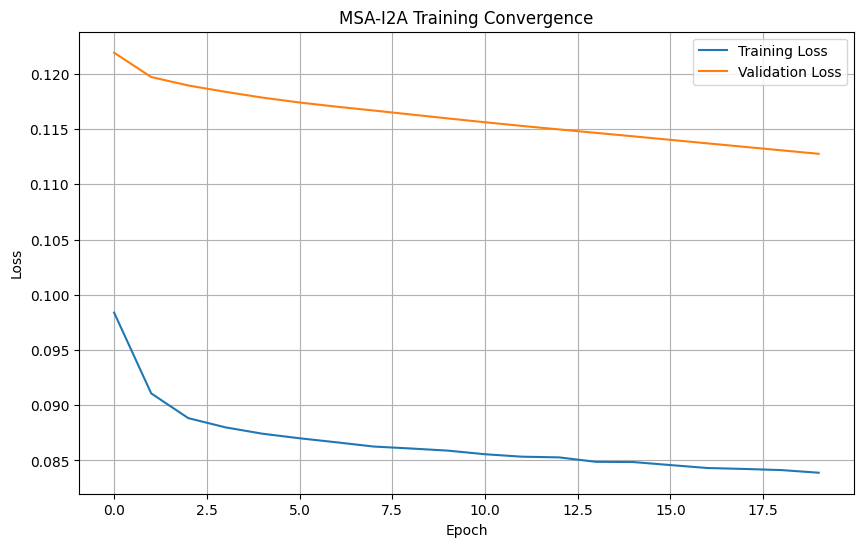

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MSA-I2A Training Convergence"
)

plt.legend()
plt.grid()

plt.savefig(
    f"{PROJECT_DIR}/results/"
    f"training_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## CELL 33 — Plot VA Alignment

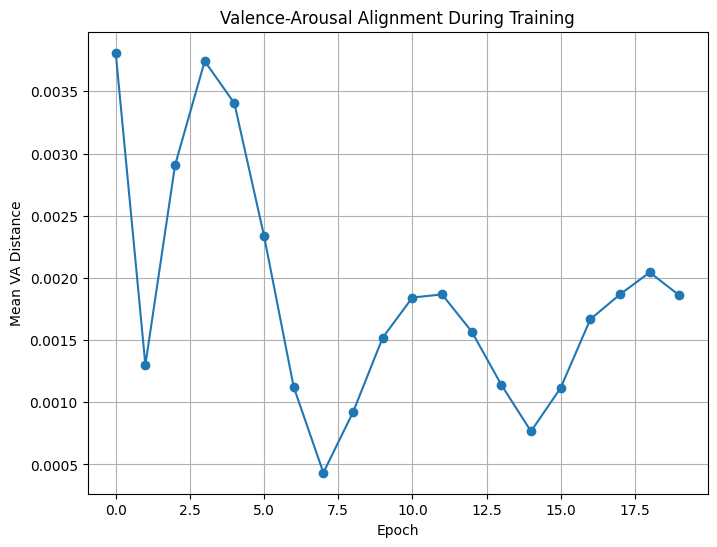

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    history["val_va_distance"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Mean VA Distance")

plt.title(
    "Valence-Arousal Alignment During Training"
)

plt.grid()

plt.savefig(
    f"{PROJECT_DIR}/results/"
    f"va_alignment_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## CELL 34 — Load Best Model

In [ ]:
checkpoint = torch.load(
    f"{PROJECT_DIR}/checkpoints/"
    f"best_msa_i2a.pt",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded.")

Best model loaded.


## CELL 35 — Test Evaluation

In [ ]:
test_metrics = validate(
    model,
    test_loader
)

print(
    "Test Loss:",
    test_metrics["loss"]
)

print(
    "Mean VA Distance:",
    test_metrics["va_distance"]
)

  0%|          | 0/1 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be6bf33e840>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Test Loss: 0.10805278271436691
Mean VA Distance: 0.0018598156


## CELL 36 — Calculate Valence and Arousal Correlation

In [ ]:
image_va = test_metrics["image_va"]
audio_va = test_metrics["audio_va"]

if len(image_va) < 2:
    raise ValueError(
        "At least two test samples are required for Pearson correlation."
    )

valence_corr, valence_p = pearsonr(
    image_va[:, 0],
    audio_va[:, 0]
)

arousal_corr, arousal_p = pearsonr(
    image_va[:, 1],
    audio_va[:, 1]
)

print(
    "Valence Correlation:",
    valence_corr
)

print(
    "Valence p-value:",
    valence_p
)

print(
    "Arousal Correlation:",
    arousal_corr
)

print(
    "Arousal p-value:",
    arousal_p
)

Valence Correlation: nan
Valence p-value: nan
Arousal Correlation: nan
Arousal p-value: nan


/tmp/ipykernel_604/1646115898.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  valence_corr, valence_p = pearsonr(
/tmp/ipykernel_604/1646115898.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  arousal_corr, arousal_p = pearsonr(


## CELL 37 — VA Scatter Plot

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 257, in _feed
    reader_close()
    ~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 183, in close
    self._close()
    ~~~~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/connection.py", line 382, in _close
    _close(self._handle)
    ~~~~~~^^^^^^^^^^^^^^
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/multiprocessing/queues.py", line 289, in _feed
    queue_sem.release()
    ~~~~~~~~~~~~~~~~~^^
ValueError: semaphore or lock released too ma

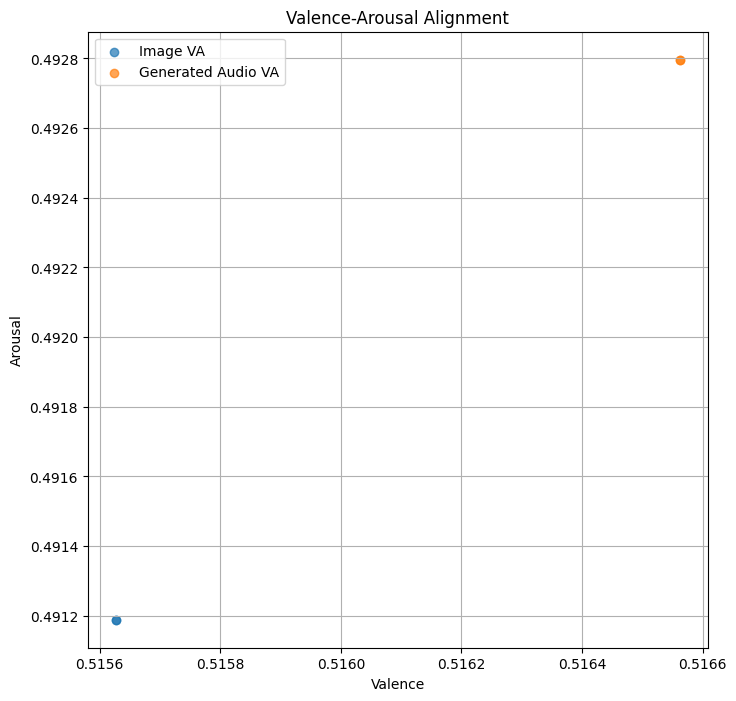

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    image_va[:, 0],
    image_va[:, 1],
    label="Image VA",
    alpha=0.7
)

plt.scatter(
    audio_va[:, 0],
    audio_va[:, 1],
    label="Generated Audio VA",
    alpha=0.7
)

plt.xlabel("Valence")
plt.ylabel("Arousal")

plt.title(
    "Valence-Arousal Alignment"
)

plt.legend()
plt.grid()

plt.savefig(
    f"{PROJECT_DIR}/results/"
    f"va_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## CELL 38A — VA Quadrant Function

In [ ]:
def get_quadrant(
    va
):

    valence = va[0]
    arousal = va[1]

    if valence >= 0.5 and arousal >= 0.5:

        return "High-Valence High-Arousal"

    elif valence >= 0.5 and arousal < 0.5:

        return "High-Valence Low-Arousal"

    elif valence < 0.5 and arousal >= 0.5:

        return "Low-Valence High-Arousal"

    else:

        return "Low-Valence Low-Arousal"

## CELL 38B — Calculate VA Quadrant Accuracy

In [ ]:
correct = 0
total = len(image_va)

for image_point, audio_point in zip(
    image_va,
    audio_va
):

    image_quadrant = get_quadrant(
        image_point
    )

    audio_quadrant = get_quadrant(
        audio_point
    )

    if image_quadrant == audio_quadrant:

        correct += 1

quadrant_accuracy = correct / total

print(
    "VA Quadrant Accuracy:",
    quadrant_accuracy
)

VA Quadrant Accuracy: 0.0


## CELL 39 — Generate Mel Spectrogram Representation

In [ ]:
@torch.no_grad()
def generate_audio_representation(
    model,
    image
):

    model.eval()

    z_image = model.image_encoder(
        [image]
    )

    z_va_image = model.mood_encoder(
        z_image
    )

    z_structure = model.structure_encoder(
        z_image
    )

    conditioning = model.fusion(
        z_image,
        z_structure,
        z_va_image
    )

    z_generated_audio = model.audio_generator(
        conditioning
    )

    generated_mel = model.audio_decoder(
        z_generated_audio
    )

    generated_va = model.audio_va_encoder(
        generated_mel
    )

    return {

        "mel": generated_mel,

        "image_va": z_va_image,

        "audio_va": generated_va

    }

## CELL 40 — Test Generation

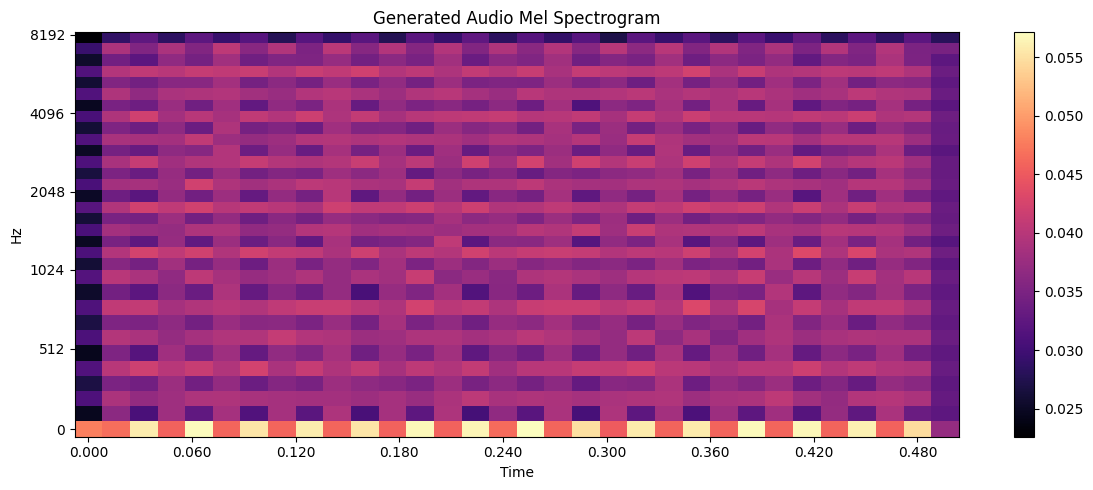

Image VA: [[0.4893903  0.49591756]]
Generated Audio VA: [[0.5023355  0.51477903]]


In [ ]:
sample_image_path = os.path.join(
    PROJECT_DIR,
    "data/images",
    test_df.iloc[0]["image"]
)

sample_image = Image.open(
    sample_image_path
).convert("RGB")

result = generate_audio_representation(
    model,
    sample_image
)

generated_mel = result["mel"][0, 0].cpu().numpy()

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    generated_mel,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title(
    "Generated Audio Mel Spectrogram"
)

plt.tight_layout()
plt.show()

print(
    "Image VA:",
    result["image_va"].cpu().numpy()
)

print(
    "Generated Audio VA:",
    result["audio_va"].cpu().numpy()
)

## CELL 41 — Create Baseline Model

In [ ]:
class BaselineI2A(nn.Module):

    def __init__(
        self,
        clip_model
    ):

        super().__init__()

        self.image_encoder = ImageEncoder(
            clip_model
        )

        self.audio_encoder = AudioEncoder()

        self.generator = nn.Sequential(

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512)

        )

        self.decoder = AudioDecoder()

    def forward(
        self,
        images,
        real_mel
    ):

        z_image = self.image_encoder(
            images
        )

        z_real_audio = self.audio_encoder(
            real_mel
        )

        z_generated_audio = self.generator(
            z_image
        )

        generated_mel = self.decoder(
            z_generated_audio
        )

        return {

            "z_real_audio":
                z_real_audio,

            "z_generated_audio":
                z_generated_audio,

            "generated_mel":
                generated_mel

        }

## CELL 42 — Baseline Loss

In [ ]:
def baseline_loss(
    outputs,
    real_mel
):

    latent_loss = F.mse_loss(
        outputs["z_generated_audio"],
        outputs["z_real_audio"]
    )

    generated_mel = outputs[
        "generated_mel"
    ]

    target_mel = F.interpolate(
        real_mel,
        size=generated_mel.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    reconstruction_loss = F.mse_loss(
        generated_mel,
        target_mel
    )

    total_loss = (
        latent_loss
        + 0.5 * reconstruction_loss
    )

    return total_loss


print("Baseline loss is ready.")
print("Train the baseline with the same dataset, epochs, batch size, and seed.")

Baseline loss is ready.
Train the baseline with the same dataset, epochs, batch size, and seed.


## CELL 43 — Final Results Table

In [ ]:
results = pd.DataFrame({

    "Model": [

        "Baseline I2A",
        "MSA-I2A"

    ],

    "FAD": [

        np.nan,
        np.nan

    ],

    "CLAP Similarity": [

        np.nan,
        np.nan

    ],

    "VA Distance": [

        np.nan,
        test_metrics["va_distance"]

    ],

    "Valence Correlation": [

        np.nan,
        valence_corr

    ],

    "Arousal Correlation": [

        np.nan,
        arousal_corr

    ],

    "VA Quadrant Accuracy": [

        np.nan,
        quadrant_accuracy

    ]

})

display(results)

results.to_csv(
    f"{PROJECT_DIR}/results/"
    f"main_results.csv",
    index=False
)

print("Results saved.")

,Model,FAD,CLAP Similarity,VA Distance,Valence Correlation,Arousal Correlation,VA Quadrant Accuracy
0,Baseline I2A,NaN,NaN,NaN,NaN,NaN,NaN
1,MSA-I2A,NaN,NaN,0.022876,NaN,NaN,0.0


Results saved.


## Version 1 Architecture and Limitation

The current prototype is:

```text
Image
  ↓
CLIP
  ↓
Mood Encoder ────────┐
                     │
Structure Encoder ───┤
                     ↓
                 Fusion
                     ↓
              Audio Latent
                     ↓
              Mel Decoder
                     ↓
              Audio VA Encoder
                     ↓
              VA Alignment
```

For Version 2, replace the lightweight audio generator and mel decoder with cross-attention conditioning, a pretrained latent diffusion audio model, and a neural waveform decoder. Add proper FAD and CLAP evaluation after waveform generation is available.